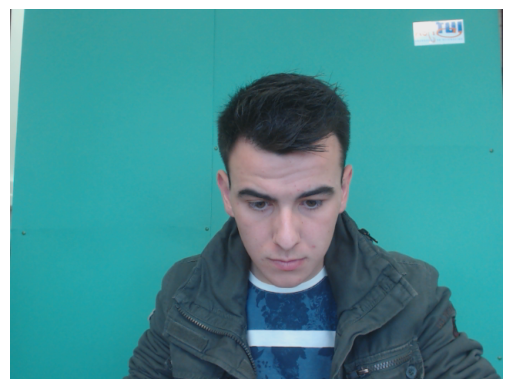

In [ ]:
import os 
import cv2 
import matplotlib.pyplot as plt 
from IPython.display import clear_output
import numpy as np 

path = os.path.join('data','UBFC-RPPG-Dataset')
subjects = os.listdir(path) 

""""
1. Check if there are any missing subjects in the dataset."""


nums_so_far = sorted([int(subject[7:]) for subject in subjects])
big = nums_so_far[-1]
small = nums_so_far[0]
expected = set(range(small,big+1))
actual = set(nums_so_far) 
print(f"Missing subjects: {expected-actual}") #  {2, 6, 7, 19, 21, 28, 29} from our dataset . 
"""

2. Look at the videos and see if they are all in the same format and length. 

"""





sample_subject = subjects[0]
sample_video_path = os.path.join(path, sample_subject,'vid.avi')


cap = cv2.VideoCapture(sample_video_path)
success, frame = cap.read()
f_count = 0 


while success and f_count < 50: # show 5 frames 
    clear_output(wait=True)
    
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis('off')
    plt.show()
    
    
    
    success, frame = cap.read()
    f_count += 1
    
cap.release()





In [ ]:
#take all subjects and all their videos and check if they are all the same length as their corresponding ground truth

faulty_subjects = []
for subject in subjects:
    video_path = os.path.join(path,subject,'vid.avi')
    gt_path = os.path.join(path,subject,'ground_truth.txt')
    gt_data = np.loadtxt(gt_path)
    cap = cv2.VideoCapture(video_path)   
    count = 0
    while True: 
        success, frame = cap.read()
        if not success:
            break 
        count += 1
    cap.release() 
    if count != gt_data.shape[1]:
        faulty_subjects.append(subject)



In [ ]:
faulty_subjects 

[]